# Ejercicio 1.
Genera una imagen semejante a una diana de tiro al blanco como se aprecia en la imagen a continuación
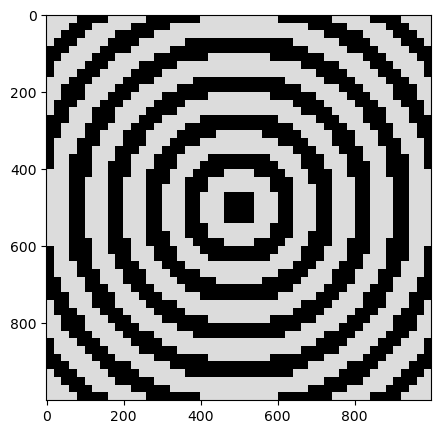


# Ejercicio 2.
Genera la imagen tal cual se muestra acontinuación, tomar en cuenta el tamaño 
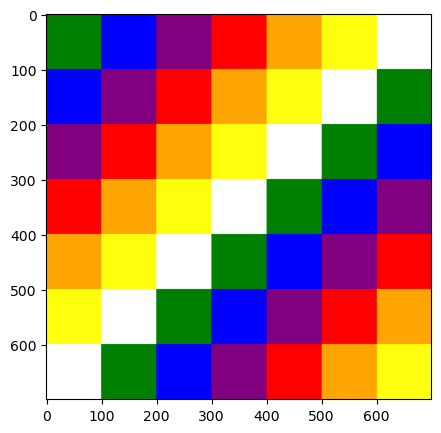

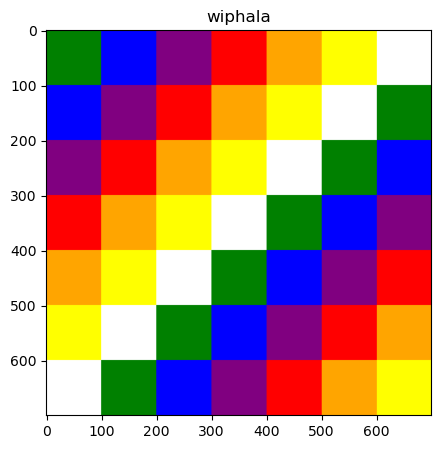

In [13]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize']=[10,5]

# Definición de colores de la whipala
VERDE = [0, 128, 0]
AZUL = [0, 0, 255]
MORADO = [128, 0, 128]
ROJO = [255, 0, 0]
NARANJA = [255, 165, 0]
AMARILLO = [255, 255, 0]
BLANCO = [255, 255, 255]

# Matriz de colores
matriz_colores = [
    [VERDE, AZUL, MORADO, ROJO, NARANJA, AMARILLO, BLANCO],
    [AZUL, MORADO, ROJO, NARANJA, AMARILLO, BLANCO, VERDE],
    [MORADO, ROJO, NARANJA, AMARILLO, BLANCO, VERDE, AZUL],
    [ROJO, NARANJA, AMARILLO, BLANCO, VERDE, AZUL, MORADO],
    [NARANJA,AMARILLO, BLANCO, VERDE, AZUL, MORADO, ROJO],
    [AMARILLO, BLANCO,VERDE, AZUL, MORADO, ROJO, NARANJA],
    [BLANCO, VERDE, AZUL, MORADO, ROJO, NARANJA, AMARILLO]
]

num_filas = len(matriz_colores)
num_columnas = len(matriz_colores[0])
tamano_cuadrado = 100
tamano_total_x = num_columnas * tamano_cuadrado
tamano_total_y = num_filas * tamano_cuadrado

imagen = np.zeros((tamano_total_y, tamano_total_x, 3))

for i in range(num_filas):
    for j in range(num_columnas):
        color_actual = matriz_colores[i][j]
        for x in range(tamano_cuadrado):
            for y in range(tamano_cuadrado):
                imagen[i * tamano_cuadrado + x, j * tamano_cuadrado + y] = color_actual

imagen_completa = np.array(imagen, dtype=int)

plt.figure()
plt.imshow(imagen_completa.astype(np.uint8))
plt.title('wiphala')
plt.axis('on')
plt.savefig('wiphala.jpeg', dpi=300, bbox_inches='tight')
plt.show()


# Ejercicio 3.
Tomando en cuenta la imagen1.jpg elige un punto de interés al azar (funcion randomica), solariza y posteriza la imagen, realiza un tratamiento de umbralización(el de preferencia), mezcla tecnicas y obtiene un filtro artistico,lista todas las imágenes con sus correspondientes titulos, guarda todas las imágenes resultantes con sus nombres.

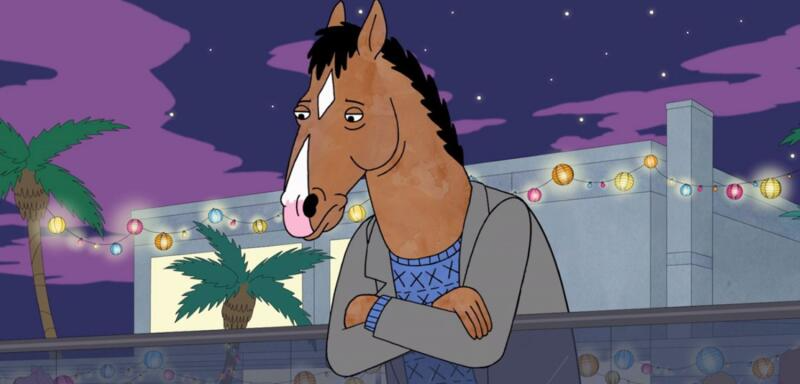

Punto de interés: (602, 165)


C:\Users\NITRO V 15\AppData\Local\Temp\ipykernel_2204\1329735546.py:44: RuntimeWarning: overflow encountered in scalar subtract
  img_random[i,j] = max(0, imagen_gray[i,j] - random.randint(20, 50))
C:\Users\NITRO V 15\AppData\Local\Temp\ipykernel_2204\1329735546.py:42: RuntimeWarning: overflow encountered in scalar add
  img_random[i,j] = min(255, imagen_gray[i,j] + random.randint(20, 50))


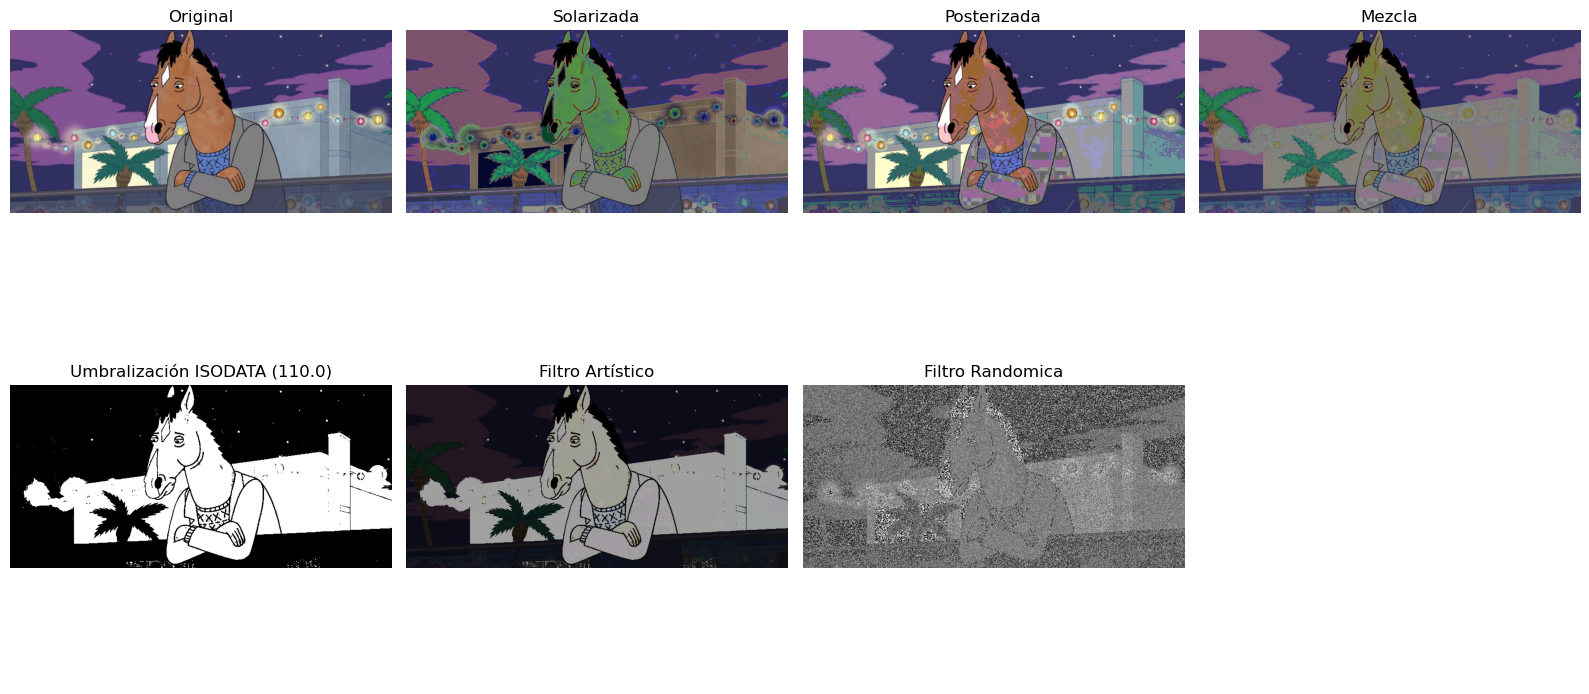

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

def solarizar(imagen, umbral):
    img_sol=np.where(imagen<umbral, imagen, 255-imagen)
    return img_sol

def posterizar(imagen, niveles):
    factor_escala=255/niveles
    img_pos=np.round(imagen/factor_escala)*factor_escala
    return img_pos.astype(np.uint8)

def isodata(image):
    umbral = 128
    while True:
        grupo1 = image[image <= umbral]
        grupo2 = image[image > umbral]
        media1 = np.mean(grupo1)
        media2 = np.mean(grupo2)
        nuevo_umbral = (media1 + media2) / 2
        if abs(nuevo_umbral - umbral) < 0.5:
            break
        umbral = nuevo_umbral
    return umbral

def randomica(imagen_gray):
    # Filtro random 
    alto, ancho = imagen_gray.shape
    img_random = np.zeros_like(imagen_gray)
    
    for i in range(alto):
        for j in range(ancho):
            efecto = random.choice(['normal', 'invertir', 'brillar', 'oscurecer'])
            
            if efecto == 'normal':
                img_random[i,j] = imagen_gray[i,j]
            elif efecto == 'invertir':
                img_random[i,j] = 255 - imagen_gray[i,j]
            elif efecto == 'brillar':
                img_random[i,j] = min(255, imagen_gray[i,j] + random.randint(20, 50))
            else:  # oscurecer
                img_random[i,j] = max(0, imagen_gray[i,j] - random.randint(20, 50))
    
    return img_random.astype(np.uint8)

# Cargar imagen
imagen = cv2.imread('imagen1.jpg')

# 1. Punto de interés 
alto, ancho, _ = imagen.shape
punto_x = random.randint(0, ancho-1)
punto_y = random.randint(0, alto-1)
print(f"Punto de interés: ({punto_x}, {punto_y})")

# 2. Solarizar
img_solarizada = solarizar(imagen, 100)

# 3. Posterizar
img_posterizada = posterizar(imagen, 5)

# 4. Umbralización ISODATA
img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
umbral_isodata = isodata(img_gray)
_, img_umbralizada = cv2.threshold(img_gray, umbral_isodata, 255, cv2.THRESH_BINARY)

# 5. Mezcla de técnicas
img_mezcla = cv2.addWeighted(img_solarizada, 0.5, img_posterizada, 0.5, 0)

# 6. Filtro artístico
img_umbralizada_3c = cv2.cvtColor(img_umbralizada, cv2.COLOR_GRAY2BGR)
img_artistica = cv2.addWeighted(img_solarizada, 0.25, img_posterizada, 0.25, 0)
img_artistica = cv2.addWeighted(img_artistica, 0.5, img_umbralizada_3c, 0.5, 0)

# 7. Filtro random
img_randomica = randomica(img_gray)

# Mostrar todas las imágenes
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

axes[0,0].imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
axes[0,0].set_title('Original')
axes[0,0].axis('off')

axes[0,1].imshow(cv2.cvtColor(img_solarizada, cv2.COLOR_BGR2RGB))
axes[0,1].set_title('Solarizada')
axes[0,1].axis('off')

axes[0,2].imshow(cv2.cvtColor(img_posterizada, cv2.COLOR_BGR2RGB))
axes[0,2].set_title('Posterizada')
axes[0,2].axis('off')

axes[0,3].imshow(cv2.cvtColor(img_mezcla, cv2.COLOR_BGR2RGB))
axes[0,3].set_title('Mezcla')
axes[0,3].axis('off')

axes[1,0].imshow(img_umbralizada, cmap='gray')
axes[1,0].set_title(f'Umbralización ISODATA ({umbral_isodata:.1f})')
axes[1,0].axis('off')

axes[1,1].imshow(cv2.cvtColor(img_artistica, cv2.COLOR_BGR2RGB))
axes[1,1].set_title('Filtro Artístico')
axes[1,1].axis('off')

axes[1,2].imshow(cv2.cvtColor(img_randomica, cv2.COLOR_BGR2RGB))
axes[1,2].set_title('Filtro Randomica')
axes[1,2].axis('off')

axes[1,3].axis('off')

plt.tight_layout()
plt.savefig('ejercicio3_completo.png', dpi=300, bbox_inches='tight')
plt.show()

# Ejercicio 4.
Genera un avatar, basandote en una imagen tuya que usaste en practicas anteriores, este avatar debe tener filtros y/o umbralizaciones.
Guarda la imagen 

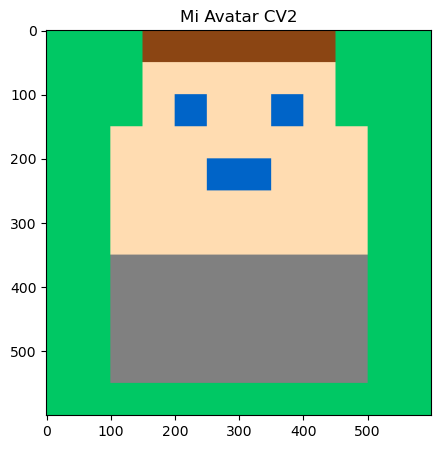

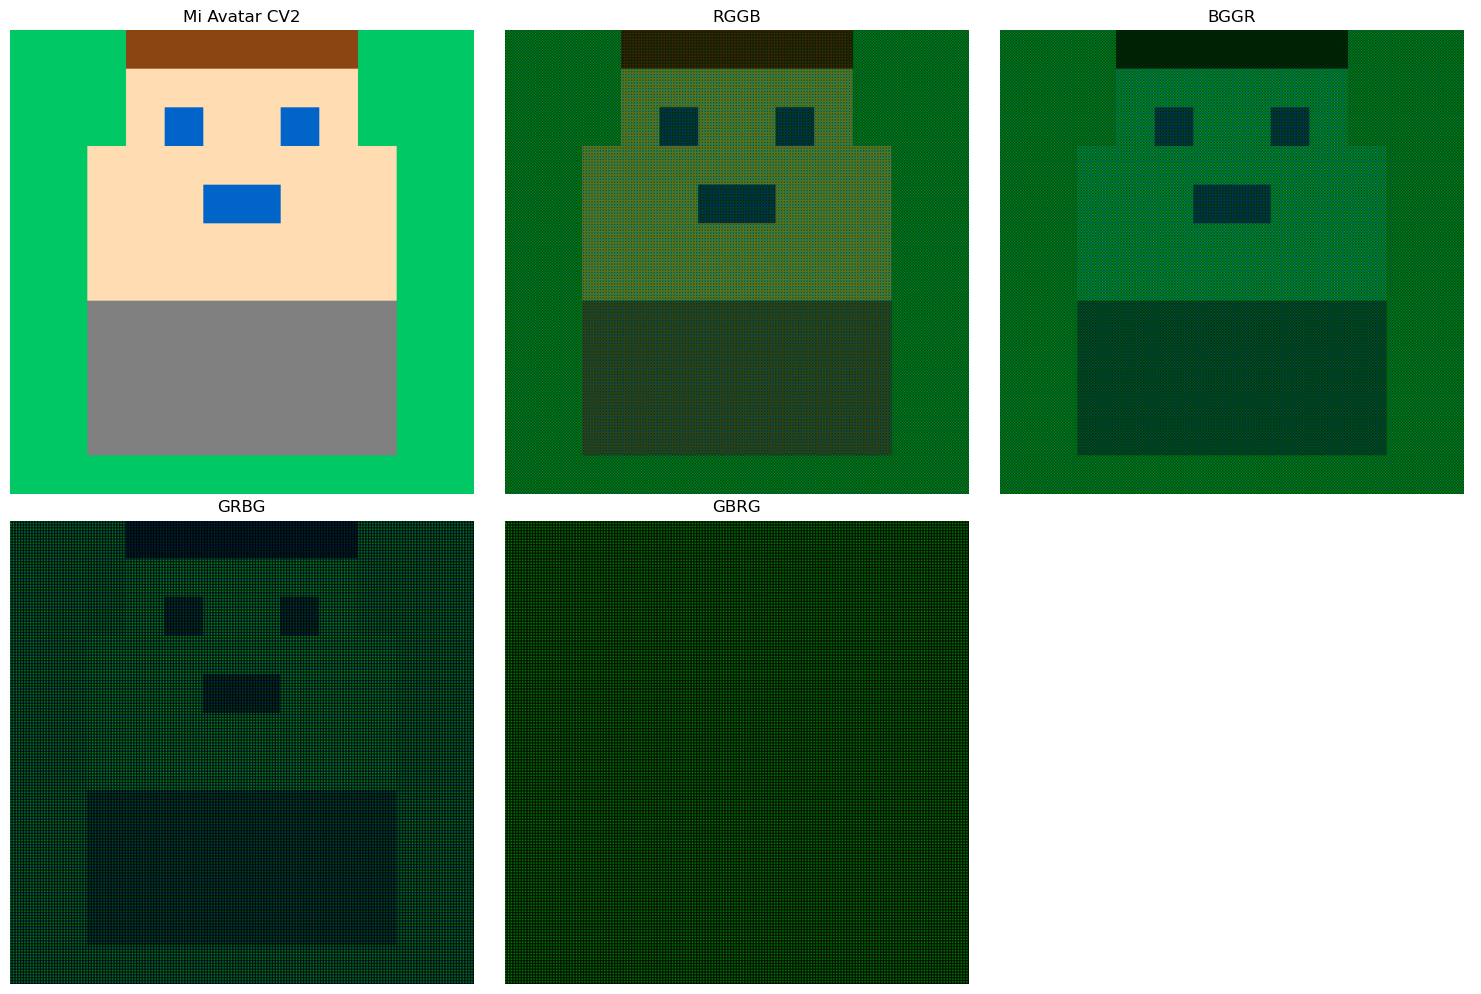

In [1]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize']=[10,5]

# Avatar personalizado
size_cuadrante = 50
size_total = size_cuadrante * 12
imagen = np.zeros((size_total, size_total, 3), dtype=np.uint8)

# Definir colores personalizados
PIEL_CLARA = [255, 220, 177]  # tono piel claro
PIEL_MEDIA = [255, 200, 150]   # tono piel medio
CAFE = [139, 69, 19]           # café oscuro
AZUL_CV2 = [0, 100, 200]      # azul característico cv2
VERDE_CV2 = [0, 200, 100]     # verde cv2
GRIS_CV2 = [128, 128, 128]     # gris cv2

# Matriz del avatar personalizado (12x12)
# 0 = piel clara, 1 = café, 2 = azul cv2, 3 = verde cv2, 4 = gris cv2, 5 = piel media
avatar_matrix = [
    [3,3,3,1,1,1,1,1,1,3,3,3],
    [3,3,3,0,0,0,0,0,0,3,3,3],
    [3,3,3,0,2,0,0,2,0,3,3,3],
    [3,3,0,0,0,0,0,0,0,0,3,3],
    [3,3,0,0,0,2,2,0,0,0,3,3],
    [3,3,0,0,0,0,0,0,0,0,3,3],
    [3,3,0,0,0,0,0,0,0,0,3,3],
    [3,3,4,4,4,4,4,4,4,4,3,3],
    [3,3,4,4,4,4,4,4,4,4,3,3],
    [3,3,4,4,4,4,4,4,4,4,3,3],
    [3,3,4,4,4,4,4,4,4,4,3,3],
    [3,3,3,3,3,3,3,3,3,3,3,3]
]

# Dibuja el avatar
for i in range(12):
    for j in range(12):
        for x in range(size_cuadrante):
            for y in range(size_cuadrante):
                if avatar_matrix[i][j] == 0:
                    imagen[i*size_cuadrante + x, j*size_cuadrante + y] = PIEL_CLARA
                elif avatar_matrix[i][j] == 1:
                    imagen[i*size_cuadrante + x, j*size_cuadrante + y] = CAFE
                elif avatar_matrix[i][j] == 2:
                    imagen[i*size_cuadrante + x, j*size_cuadrante + y] = AZUL_CV2
                elif avatar_matrix[i][j] == 3:
                    imagen[i*size_cuadrante + x, j*size_cuadrante + y] = VERDE_CV2
                elif avatar_matrix[i][j] == 4:
                    imagen[i*size_cuadrante + x, j*size_cuadrante + y] = GRIS_CV2
                elif avatar_matrix[i][j] == 5:
                    imagen[i*size_cuadrante + x, j*size_cuadrante + y] = PIEL_MEDIA

imagen_completa = np.array(imagen, dtype=int)

plt.figure()
plt.imshow(imagen)
plt.title('Mi Avatar CV2')
plt.axis('on')
plt.savefig('mi_avatar_cv2.png')
plt.show()

# Filtros Bayer
def separar_canales(imagen):
    return imagen[:, :, 0], imagen[:, :, 1], imagen[:, :, 2]

def aplicar_bayer(rojo, verde, azul, patron):
    alto, ancho = rojo.shape
    resultado = np.zeros((alto, ancho, 3), dtype=np.uint8)
    
    if patron == "RGGB":
        resultado[0::2, 0::2, 0] = rojo[0::2, 0::2]
        resultado[0::2, 1::2, 1] = verde[0::2, 1::2]
        resultado[1::2, 0::2, 1] = verde[1::2, 0::2]
        resultado[1::2, 1::2, 2] = azul[1::2, 1::2]
    
    elif patron == "BGGR":
        resultado[0::2, 0::2, 2] = azul[0::2, 0::2]
        resultado[0::2, 1::2, 1] = verde[0::2, 1::2]
        resultado[1::2, 0::2, 1] = verde[1::2, 0::2]
        resultado[1::2, 1::2, 0] = rojo[1::2, 1][2]
    
    elif patron == "GRBG":
        resultado[0::2, 0::2, 1] = verde[0::2, 0::2]
        resultado[0::2, 1::2, 0] = rojo[0::2, 1][2]
        resultado[1::2, 0::2, 2] = azul[1::2, 0][2]
        resultado[1::2, 1][2, 1] = verde[1::2, 1][2]
    
    elif patron == "GBRG":
        resultado[0::2, 0::2, 1] = verde[0::2, 0][2]
        resultado[0::2, 1][2, 2] = azul[0::2, 1][2]
        resultado[1::2, 0][2, 0] = rojo[1::2, 0][2]
        resultado[1::2, 1][2, 1] = verde[1::2, 1][2]
    
    return resultado

# Separar canales y aplicar patrones
rojo, verde, azul = separar_canales(imagen)
patrones = ["RGGB", "BGGR", "GRBG", "GBRG"]
resultados = {}

for patron in patrones:
    resultados[patron] = aplicar_bayer(rojo, verde, azul, patron)

# Mostrar resultados
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0,0].imshow(imagen)
axes[0,0].set_title('Mi Avatar CV2')
axes[0,0].axis('off')

axes[0,1].imshow(resultados["RGGB"])
axes[0,1].set_title('RGGB')
axes[0,1].axis('off')

axes[0,2].imshow(resultados["BGGR"])
axes[0,2].set_title('BGGR')
axes[0,2].axis('off')

axes[1,0].imshow(resultados["GRBG"])
axes[1,0].set_title('GRBG')
axes[1,0].axis('off')

axes[1,1].imshow(resultados["GBRG"])
axes[1,1].set_title('GBRG')
axes[1,1].axis('off')

axes[1,2].axis('off')

plt.tight_layout()
plt.savefig('mi_avatar_bayer.png', dpi=300, bbox_inches='tight')
plt.show()